# 06 — Méthodes ML géo-aware (GP, Random Forest, SADIE)

Trois méthodes sont comparées au krigeage ordinaire (référence du notebook 03)
et à une baseline constante :

- **MaternGPRegressor** — GP régression sur ``obs ∈ [0, 1]`` avec noyau Matérn.
- **MaternGPClassifier** — GP classification sur ``obs > 0.5`` (comparable à un
  pipeline historique binaire).
- **SpatialRandomForest** — RF avec features ``(x, y, dist_bord, dist_capteur,
  val_capteur)``.
- **SADIE** — exploratoire (fournit aussi une interpolation IDW).
- **OrdinaryKrigingIndicator / UniversalKrigingEdge / IndicatorKrigingThreshold** —
  variantes géostatistiques.
- **BaselineConstant** — borne inférieure (prévalence empirique constante).

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aphid_spatial.evaluation.metrics import evaluate_all
from aphid_spatial.methods.exploration import BaselineConstant
from aphid_spatial.methods.geostatistics import (
    IndicatorKrigingThreshold,
    OrdinaryKrigingIndicator,
    UniversalKrigingEdge,
)
from aphid_spatial.methods.gp import MaternGPClassifier, MaternGPRegressor
from aphid_spatial.methods.ml import SpatialRandomForest
from aphid_spatial.methods.sadie import SADIE
from aphid_spatial.simulation import (
    Field,
    FieldConfig,
    SensorConfig,
    place_sensors,
    simulate_field,
)
from aphid_spatial.visualization.maps import plot_prediction

logging.basicConfig(level=logging.WARNING, format="%(name)s | %(message)s")
FIG_DIR = Path("../outputs/figures")
RES_DIR = Path("../outputs/results")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
data_path = Path("../data/simulated/field_default.npz")
if data_path.exists():
    field = Field.load(data_path)
else:
    field = simulate_field(FieldConfig(seed=42))

readings = place_sensors(
    field, SensorConfig(n_sensors=20, placement="uniform", n_observations=50, seed=2024)
)
print(f"capteurs : {readings.coords.shape[0]}")
print(f"obs moyenne : {readings.obs.mean():.3f}, prob_local moyenne : {readings.prob_local.mean():.3f}")
print(f"prévalence vraie : {field.presence.mean():.3f}, p moyenne : {field.prob.mean():.3f}")

capteurs : 20
obs moyenne : 0.242, prob_local moyenne : 0.241
prévalence vraie : 0.239, p moyenne : 0.240


## Ajustement des méthodes et calcul des métriques

Toutes les méthodes utilisent les mêmes capteurs ; la comparaison est donc équitable.

In [3]:
methods = [
    BaselineConstant(),
    OrdinaryKrigingIndicator(),
    UniversalKrigingEdge(),
    IndicatorKrigingThreshold(threshold=0.5),
    MaternGPRegressor(length_scale=15.0),
    MaternGPClassifier(threshold=0.5),
    SpatialRandomForest(n_estimators=200, max_depth=8),
    SADIE(n_permutations=100),
]

predictions = {}
uncertainties = {}
rows = []
for m in methods:
    m.fit(readings, field)
    p = m.predict_proba(field.coords)
    sigma = m.predict_uncertainty(field.coords)
    predictions[m.name] = p
    uncertainties[m.name] = sigma
    rows.append({"method": m.name, **evaluate_all(field.presence, p, p_true=field.prob)})

df = pd.DataFrame(rows).sort_values("auc_roc", ascending=False)
df.to_csv(RES_DIR / "06_ml_methods_metrics.csv", index=False)
df

,method,auc_roc,auc_pr,brier,log_loss,prevalence_true,prevalence_pred,mae_prob,rmse_prob
2,universal_kriging_edge,0.681079,0.382612,0.169144,0.515432,0.23929,0.246609,0.100880,0.140343
7,sadie_simplified,0.679738,0.397125,0.168672,0.515378,0.23929,0.256711,0.103875,0.138807
1,ordinary_kriging_indicator,0.672099,0.379204,0.169846,0.517349,0.23929,0.255963,0.105062,0.142466
4,gp_matern_regressor,0.658255,0.363177,0.171958,0.522665,0.23929,0.248715,0.111977,0.149865
5,gp_matern_classifier,0.635911,0.355257,0.177828,0.537778,0.23929,0.263062,0.127145,0.168536
3,indicator_kriging_threshold,0.630265,0.365992,0.197454,0.739498,0.23929,0.121413,0.167001,0.219432
6,spatial_random_forest,0.622308,0.349438,0.174703,0.531199,0.23929,0.233919,0.115181,0.159953
0,baseline_constant,0.500000,0.239290,0.182038,0.550280,0.23929,0.242000,0.141080,0.180932


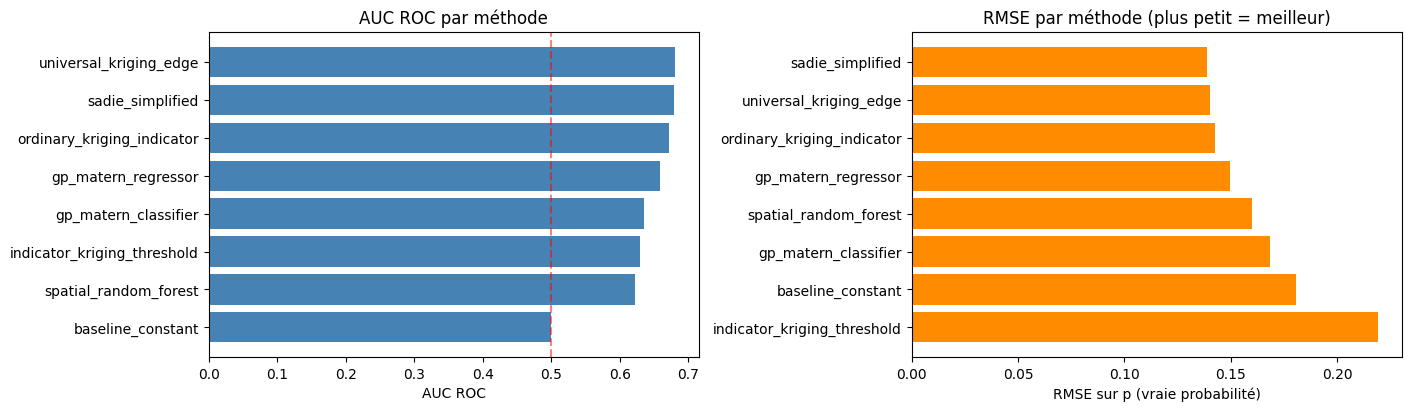

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
df_sorted = df.sort_values("auc_roc")
axes[0].barh(df_sorted["method"], df_sorted["auc_roc"], color="steelblue")
axes[0].set_xlabel("AUC ROC")
axes[0].set_title("AUC ROC par méthode")
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.5)

df_sorted2 = df.sort_values("rmse_prob", ascending=False)
axes[1].barh(df_sorted2["method"], df_sorted2["rmse_prob"], color="darkorange")
axes[1].set_xlabel("RMSE sur p (vraie probabilité)")
axes[1].set_title("RMSE par méthode (plus petit = meilleur)")
fig.savefig(FIG_DIR / "06_ml_methods_comparison.png", dpi=150)
plt.show()

## Cartes prédites des méthodes les mieux classées

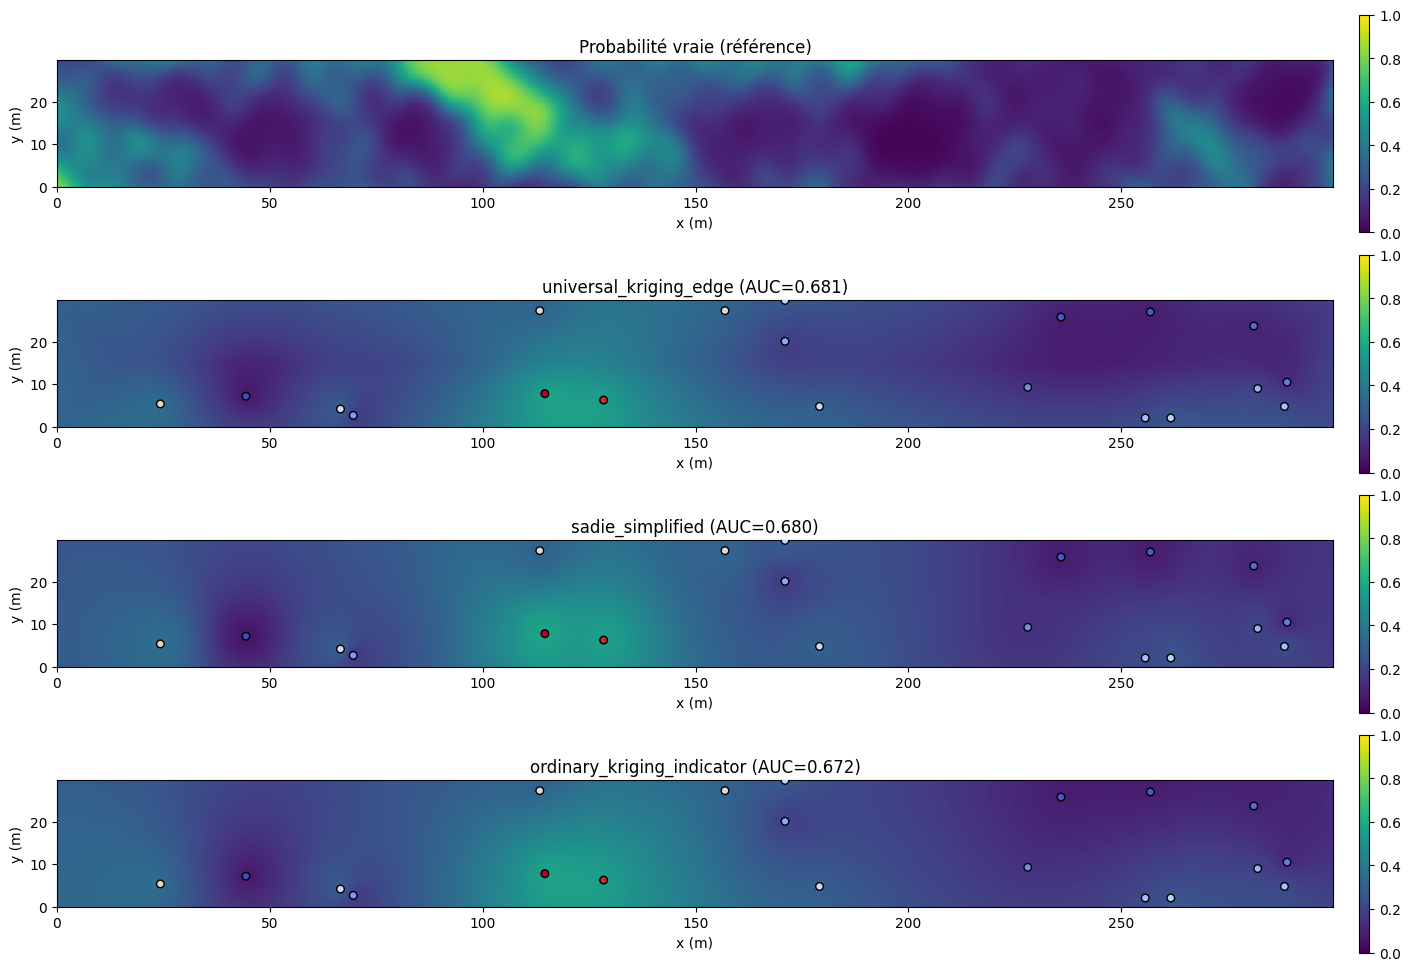

In [5]:
top3 = df.head(3)["method"].tolist()
fig, axes = plt.subplots(len(top3) + 1, 1, figsize=(14, 2.4 * (len(top3) + 1)), constrained_layout=True)
# référence
from aphid_spatial.visualization.maps import plot_field
plot_field(field, "prob", ax=axes[0], title="Probabilité vraie (référence)")
for ax, name in zip(axes[1:], top3, strict=True):
    plot_prediction(predictions[name], field, ax=ax, readings=readings, title=f"{name} (AUC={df.set_index('method').loc[name, 'auc_roc']:.3f})")
fig.savefig(FIG_DIR / "06_ml_methods_top3_maps.png", dpi=150)
plt.show()

## Diagnostic SADIE

Les statistiques d'agrégation et les indices locaux ``v_i`` sont consultables
directement sur l'instance :

In [6]:
sadie = next(m for m in methods if m.name == "sadie_simplified")
print("Statistiques SADIE :")
for k, v in sadie.stats.items():
    print(f"  {k:>12} : {v:.4f}")
print(f"\nv_i positifs (clusters) : {(sadie.v_local > 0).sum()} / {sadie.v_local.size}")
print(f"v_i négatifs (gaps)     : {(sadie.v_local < 0).sum()} / {sadie.v_local.size}")

Statistiques SADIE :
           I_a : 1.1391
       p_value : 0.0300
    obs_metric : 68.1918
     perm_mean : 77.6798
      perm_std : 4.9898

v_i positifs (clusters) : 9 / 20
v_i négatifs (gaps)     : 11 / 20
